# Arabic Text Summarisation — Seq2Seq + Attention Preprocessing

**Architecture**: Bidirectional LSTM/GRU Encoder → Bahdanau/Luong Attention → LSTM/GRU Decoder

> **Stemming and stop-word removal are intentionally disabled.**  
> Both operations alter surface word forms that the decoder must regenerate when producing natural Arabic text.

In [1]:
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

pip("torch", "torchvision", "torchaudio", "--index-url",
    "https://download.pytorch.org/whl/cu121")   
pip("rouge-score")
pip("nltk")
pip("pandas")
pip("numpy")
pip("tqdm")
pip("pyarrow")          
pip("matplotlib")

import json, os, re, math, copy, time, ast
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np

import nltk
nltk.download("punkt", quiet=True)
from nltk.stem.isri import ISRIStemmer      

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from rouge_score import rouge_scorer

import gc
gc.collect()
torch.cuda.empty_cache()
torch.backends.cudnn.benchmark = True       # faster convolutions on fixed input sizes

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch   :", torch.__version__)
print("CUDA      :", torch.cuda.is_available())
print("Device    :", DEVICE)
if torch.cuda.is_available():
    print("GPU       :", torch.cuda.get_device_name(0))
    print("VRAM free :", round((torch.cuda.get_device_properties(0).total_memory
                                - torch.cuda.memory_allocated()) / 1024**3, 2), "GB")

PyTorch   : 2.5.1+cu121
CUDA      : True
Device    : cuda
GPU       : NVIDIA GeForce RTX 4080
VRAM free : 15.99 GB


## 1. Load Raw Datasets

In [2]:
def read_jsonl(file_path):
    records = []
    with open(file_path, encoding="utf-8") as f:
        for line in f:
            records.append(json.loads(line))
    return pd.DataFrame(records)

base_dir = "/content/drive/MyDrive/nlpDataset/arabsum"
train = read_jsonl(f"{base_dir}/sumarabic-1.0-train.jsonl")
valid = read_jsonl(f"{base_dir}/sumarabic-1.0-valid.jsonl")
test  = read_jsonl(f"{base_dir}/sumarabic-1.0-test.jsonl")

train["split"] = "train"
valid["split"] = "valid"
test["split"]  = "test"

df_arabsum = pd.concat([train, valid, test], ignore_index=True)
print("ArabSum shape:", df_arabsum.shape)

ArabSum shape: (2628, 11)


In [3]:
parquet_file = "/content/drive/MyDrive/nlpDataset/train-00000-of-00001.parquet"
df_parquet = pd.read_parquet(parquet_file)
print("Parquet shape:", df_parquet.shape)

Parquet shape: (3689, 3)


In [4]:
# ── Kaggle corpus ─────────────────────────────────────────────────────────
# NOTE: Contains article text only — no summaries.
#       Rows without 'summarized_text' will be dropped during merging.
kaggle_root = Path("/content/drive/MyDrive/nlpDataset/kaggle")
data_rows = []
for category_folder in kaggle_root.iterdir():
    if category_folder.is_dir():
        for txt_file in category_folder.rglob("*.txt"):
            try:
                content = txt_file.read_text(encoding="utf-8", errors="ignore")
                data_rows.append({"category": category_folder.name, "text": content})
            except Exception as err:
                print(f"Error reading {txt_file}: {err}")

df_kaggle = pd.DataFrame(data_rows)
print("Kaggle shape:", df_kaggle.shape)

Kaggle shape: (10161, 2)


In [40]:
csv_file = "/content/drive/MyDrive/nlpDataset/AbsArSumCorpus_DW_article tab lead.csv"

articles, summaries = [], []

with open(csv_file, encoding="utf-8", errors="ignore") as f:
    for line in f:
        parts = line.strip().split("\t")

        # likely format: id \t article \t lead/summary
        if len(parts) >= 3:
            articles.append(parts[1])
            summaries.append(parts[2])

df_csv = pd.DataFrame({
    "text": articles,
    "summarized_text": summaries
})

print("CSV shape:", df_csv.shape)
df_csv.head()

CSV shape: (49604, 2)


,text,summarized_text
0,"""حقق حزب """"البديل من أجل ألمانيا"""" اليميني الش...",تشير آخر استطلاعات الرأي الألمانية إلى تقدم حز...
1,"""بدأت اليوم الجمعة( 23 أيلول/ سبتمبر 2016 ) في...",بدأت محكمة ميونخ النظر في اتهامات متعلقة برجل ...
2,"""قال مسؤولون إن شخصا أصيب إصابة بالغة بعد تعرض...",أعلن حاكم كارولاينا الشمالية حالة الطورائ في م...
3,"""أعلن مسؤول في البنتاغون أن جنودا أمريكيين في ...",قالت وزارة الدفاع الأمريكية (البنتاغون) إن داع...
4,"""اجتمعت المجموعة الدولية لدعم سوريا على هامش ا...","""فشلت الولايات المتحدة وروسيا في الاتفاق على ك..."


## 2. Merge & Clean

In [41]:
final_df = pd.concat([df_arabsum, df_parquet, df_csv], ignore_index=True, sort=False)
final_df = final_df.drop_duplicates()
final_df = final_df.dropna(how="all")
final_df = final_df.dropna(subset=["summarized_text"])  # Seq2Seq needs a target
final_df = final_df.dropna(subset=["text"])             # and a source

# Guarantee string dtype
final_df["text"]            = final_df["text"].astype(str)
final_df["summarized_text"] = final_df["summarized_text"].astype(str)

print("Final dataset:", final_df.shape)
final_df.sample(5)[["text", "summarized_text"]]

Final dataset: (53271, 13)


,text,summarized_text
19164,"""دعا الأمين العام لحلف شمال الأطلسي، ينس ستولت...",دعا الأمين العام لحلف شمال الأطلسي، ينس ستولتن...
18557,"""يعقد مجلس الأمن الدولي مساء الاثنين (23 كانون...",مجلس الأمن يعقد مشاورات طارئة حول الوضع في جنو...
29935,وعثرت فرق البحث على الباخرة (سيتي أوف تشستر) ق...,قال مسؤولون أمريكيون إنه تم العثور على حطام سف...
28665,"""قتل وجرح العشرات في تفجيرين في مترو الإنفاق ف...",قتل وجرح العشرات في تفجيرين في مترو الإنفاق في...
11605,"""أعربت المستشارة الألمانية أنجيلا ميركل عن رضا...",المستشارة الألمانية تستهل زيارتها للصين بدعوة ...


## 3. Text-Processing Helpers

In [98]:
def clean_arabic_text(text: str) -> str:
    """Remove noise while preserving Arabic word tokens."""
    text = re.sub(r'http\S+|www\.\S+', '', text)       # URLs
    text = re.sub(r'\S+@\S+', '', text)                  # e-mails
    text = re.sub(r'@\w+', '', text)                      # mentions
    text = re.sub(r'#\w+', '', text)                      # #hashtags
    text = re.sub(r'<.*?>', '', text)                      # HTML tags
    text = re.sub(r'\d+', '', text)                       # digits
    text = re.sub(r'[^\w\s\u0600-\u06FF]', '', text)  # non-Arabic punctuation
    text = re.sub(r'(.)\1{2,}', r'\1', text)            # repeated characters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [99]:
def normalize_arabic(text: str) -> str:
    """Collapse orthographic variants → smaller, more consistent vocabulary."""
    text = re.sub('[إأآا]', 'ا', text)
    text = re.sub('ى',      'ي', text)
    text = re.sub('ؤ',      'و', text)
    text = re.sub('ئ',      'ي', text)
    text = re.sub('ة',      'ه', text)
    text = re.sub('گ',      'ك', text)
    return text

In [100]:
def tokenize(text: str) -> list:
    """Extract Arabic word tokens."""
    return re.findall(r'\b[\u0600-\u06FF]+\b', text)

In [10]:
# ── STEMMING — disabled for Seq2Seq ────────────────────────────────────────
# Stemming strips prefixes/suffixes, corrupting the surface forms that the
# decoder must reproduce when generating fluent Arabic summaries.
#
# _stemmer = ISRIStemmer()
# def stem_tokens(tokens: list) -> list:
#     return [_stemmer.stem(word) for word in tokens]

In [11]:
# ── STOP-WORD REMOVAL — disabled for Seq2Seq ────────────────────────────────
# Removing stop-words breaks sentence structure and disrupts the attention
# mechanism; the model cannot learn to generate fluent output from fragmented
# input. Vocabulary consistency between encoder and decoder also requires them.
#
# _STOPWORDS = {
#     "في","من","على","و","الى","عن","أن","إن","كان","ما","هذا","هذه","ذلك","او","اي"
# }
# def remove_stopwords(tokens: list) -> list:
#     return [w for w in tokens if w not in _STOPWORDS]

In [101]:
def preprocess(text: str) -> list:
    """Pipeline: clean → normalise → tokenise.
    Returns a list of Arabic tokens ready for vocabulary encoding.
    Stemming and stop-word removal are deliberately omitted for Seq2Seq.
    """
    text   = clean_arabic_text(text)
    text   = normalize_arabic(text)
    tokens = tokenize(text)
    return tokens

## 4. Apply Preprocessing

In [42]:
final_df["processed_text"]    = final_df["text"].apply(preprocess)
final_df["processed_summary"] = final_df["summarized_text"].apply(preprocess)

# Drop rows where preprocessing yields an empty sequence
final_df = final_df[final_df["processed_text"].map(len) > 0].reset_index(drop=True)
final_df = final_df[final_df["processed_summary"].map(len) > 0].reset_index(drop=True)

print("After preprocessing:", final_df.shape)
final_df[["processed_text", "processed_summary"]].head(3)

After preprocessing: (53271, 15)


,processed_text,processed_summary
0,"[كتير, من, الشباب, دلوقتي, بيفكروا, الف, مره, ...","[غلاء, المعيشه, بيخلي, الشباب, يقللوا, عدد, ال..."
1,"[الظروف, الاقتصاديه, الصعبه, خلت, كتير, من, ال...","[الوضع, الاقتصادي, المتردي, بياجل, قرارات, الج..."
2,"[موجات, التضخم, المتتاليه, اثرت, بشكل, مباشر, ...","[التضخم, بيخلي, الاسر, تعيد, حساباتها, في, قرا..."


## 5. Sequence Length Analysis & Filtering

Seq2Seq models use padded batches. Setting `MAX_SRC_LEN` / `MAX_TGT_LEN` at the
95th-percentile discards outlier-length articles without losing most of the data.
Character-level lengths are used here because the lists already contain tokens.


In [50]:
# ── §5. Sequence Length Analysis & Filtering ──────────────────────────────
src_lens = final_df["processed_text"].map(len)
tgt_lens = final_df["processed_summary"].map(len)

print("Source — mean:{:.0f}  median:{:.0f}  95th:{:.0f}  max:{}".format(
    src_lens.mean(), src_lens.median(), src_lens.quantile(0.95), src_lens.max()))
print("Target — mean:{:.0f}  median:{:.0f}  95th:{:.0f}  max:{}".format(
    tgt_lens.mean(), tgt_lens.median(), tgt_lens.quantile(0.95), tgt_lens.max()))

MAX_SRC_LEN = 500
MAX_TGT_LEN = 50
#Had to shorten to 500 because of hardware limitations while training
before = len(final_df)
final_df = final_df[
    (src_lens <= MAX_SRC_LEN) & (tgt_lens <= MAX_TGT_LEN)
].reset_index(drop=True)
after = len(final_df)

print(f"\nMAX_SRC_LEN = {MAX_SRC_LEN}, MAX_TGT_LEN = {MAX_TGT_LEN}")
print(f"Kept {after}/{before} rows ({100 * after/before:.1f}%)")

Source — mean:348  median:293  95th:800  max:2824
Target — mean:32  median:34  95th:38  max:44

MAX_SRC_LEN = 500, MAX_TGT_LEN = 50
Kept 42373/53271 rows (79.5%)


## 6. Vocabulary

Four special tokens are required:

| Token | Idx | Role |
|-------|-----|------|
| `<PAD>` | 0 | Padding — masked in loss and attention |
| `<UNK>` | 1 | Out-of-vocabulary words |
| `<SOS>` | 2 | Start-of-sequence fed to decoder at step 0 |
| `<EOS>` | 3 | End-of-sequence; decoder stops generating here |


In [51]:
class Vocabulary:
    PAD_TOKEN = "<PAD>"   # index 0
    UNK_TOKEN = "<UNK>"   # index 1
    SOS_TOKEN = "<SOS>"   # index 2
    EOS_TOKEN = "<EOS>"   # index 3

    def __init__(self, min_freq: int = 2):
        self.min_freq  = min_freq
        self.word2idx  = {}
        self.idx2word  = {}
        self._counter  = Counter()
        for tok in [self.PAD_TOKEN, self.UNK_TOKEN, self.SOS_TOKEN, self.EOS_TOKEN]:
            self._add(tok)

    def _add(self, token):
        if token not in self.word2idx:
            idx = len(self.word2idx)
            self.word2idx[token] = idx
            self.idx2word[idx]   = token

    def fit(self, token_lists):
        """Build vocab from training data only — never from val/test."""
        for tokens in token_lists:
            self._counter.update(tokens)
        for token, freq in self._counter.items():
            if freq >= self.min_freq:
                self._add(token)
        print(f"Vocabulary size: {len(self)}  (min_freq={self.min_freq})")

    def encode(self, tokens, add_sos=False, add_eos=False):
        unk = self.word2idx[self.UNK_TOKEN]
        ids = [self.word2idx.get(t, unk) for t in tokens]
        if add_sos: ids = [self.word2idx[self.SOS_TOKEN]] + ids
        if add_eos: ids = ids + [self.word2idx[self.EOS_TOKEN]]
        return ids

    def decode(self, indices, skip_special=True):
        special = {self.PAD_TOKEN, self.SOS_TOKEN, self.EOS_TOKEN}
        tokens  = [self.idx2word.get(i, self.UNK_TOKEN) for i in indices]
        if skip_special:
            tokens = [t for t in tokens if t not in special]
        return " ".join(tokens)

    def __len__(self):         return len(self.word2idx)
    def __contains__(self, t): return t in self.word2idx

    @property
    def pad_idx(self): return self.word2idx[self.PAD_TOKEN]
    @property
    def unk_idx(self): return self.word2idx[self.UNK_TOKEN]
    @property
    def sos_idx(self): return self.word2idx[self.SOS_TOKEN]
    @property
    def eos_idx(self): return self.word2idx[self.EOS_TOKEN]


In [52]:
# Build vocab from TRAINING split only
MIN_FREQ   = 3
train_mask = final_df["split"] == "train"

vocab = Vocabulary(min_freq=MIN_FREQ)
vocab.fit(
    list(final_df.loc[train_mask, "processed_text"]) +
    list(final_df.loc[train_mask, "processed_summary"])
)

print("PAD:", vocab.pad_idx, " UNK:", vocab.unk_idx,
      " SOS:", vocab.sos_idx, " EOS:", vocab.eos_idx)


Vocabulary size: 105119  (min_freq=3)
PAD: 0  UNK: 1  SOS: 2  EOS: 3


## 7. Encode & Pad Sequences

| Tensor | Content | Shape |
|--------|---------|-------|
| `src` | token IDs | `(MAX_SRC_LEN,)` |
| `tgt_input` | `<SOS>` + token IDs | `(TGT_MAX,)` |
| `tgt_output` | token IDs + `<EOS>` | `(TGT_MAX,)` |


In [53]:
def encode_and_pad(tokens, vocab, max_len, add_sos=False, add_eos=False):
    """Encode tokens, truncate to max_len, then right-pad with PAD index."""
    ids  = vocab.encode(tokens, add_sos=add_sos, add_eos=add_eos)
    ids  = ids[:max_len]                               # truncate
    ids += [vocab.pad_idx] * (max_len - len(ids))      # pad
    return torch.tensor(ids, dtype=torch.long)

TGT_MAX = MAX_TGT_LEN + 1   # +1 to accommodate the extra SOS or EOS token

final_df["src_ids"] = final_df["processed_text"].apply(
    lambda t: encode_and_pad(t, vocab, MAX_SRC_LEN))

final_df["tgt_input_ids"] = final_df["processed_summary"].apply(
    lambda t: encode_and_pad(t, vocab, TGT_MAX, add_sos=True))    # <SOS> + tokens

final_df["tgt_output_ids"] = final_df["processed_summary"].apply(
    lambda t: encode_and_pad(t, vocab, TGT_MAX, add_eos=True))    # tokens + <EOS>

print("Encoding complete.")
print("src shape (row 0)       :", final_df["src_ids"].iloc[0].shape)
print("tgt_input shape (row 0) :", final_df["tgt_input_ids"].iloc[0].shape)
print("tgt_output shape (row 0):", final_df["tgt_output_ids"].iloc[0].shape)


Encoding complete.
src shape (row 0)       : torch.Size([500])
tgt_input shape (row 0) : torch.Size([51])
tgt_output shape (row 0): torch.Size([51])


## 8. PyTorch Dataset & DataLoaders

In [54]:
import torch
from torch.utils.data import Dataset, DataLoader

class SummarisationDataset(Dataset):
    """Each item returns three tensors consumed by the Seq2Seq model:

        src          — encoder input          shape: (MAX_SRC_LEN,)
        tgt_input    — decoder input  (SOS+)  shape: (TGT_MAX,)
        tgt_output   — decoder target (+EOS)  shape: (TGT_MAX,)
    """
    def __init__(self, dataframe: pd.DataFrame):
        self.src     = list(dataframe["src_ids"])
        self.tgt_in  = list(dataframe["tgt_input_ids"])
        self.tgt_out = list(dataframe["tgt_output_ids"])

    def __len__(self): return len(self.src)

    def __getitem__(self, idx):
        return {
            "src"       : self.src[idx],
            "tgt_input" : self.tgt_in[idx],
            "tgt_output": self.tgt_out[idx],
        }


In [55]:
df_train = final_df[final_df["split"] == "train"].reset_index(drop=True)
df_valid = final_df[final_df["split"] == "valid"].reset_index(drop=True)
df_test  = final_df[final_df["split"] == "test" ].reset_index(drop=True)

# Fallback: if split column is absent, do an 80/10/10 random split
if df_train.empty:
    from sklearn.model_selection import train_test_split
    tr, tmp           = train_test_split(final_df, test_size=0.20, random_state=42)
    df_valid, df_test = train_test_split(tmp, test_size=0.50, random_state=42)
    df_train = tr

print(f"Train:{len(df_train)}  Valid:{len(df_valid)}  Test:{len(df_test)}")


Train:33846  Valid:4244  Test:4283


In [56]:
BATCH_SIZE  = 64
NUM_WORKERS = 0   

train_loader = DataLoader(SummarisationDataset(df_train),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
valid_loader = DataLoader(SummarisationDataset(df_valid),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(SummarisationDataset(df_test),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Batches — train:{len(train_loader)}  valid:{len(valid_loader)}  test:{len(test_loader)}")

# Sanity-check shapes
batch = next(iter(train_loader))
print("\nSample batch shapes:")
for k, v in batch.items():
    print(f"  {k:<12}: {tuple(v.shape)}")


Batches — train:529  valid:67  test:67

Sample batch shapes:
  src         : (64, 500)
  tgt_input   : (64, 51)
  tgt_output  : (64, 51)


In [57]:
# Quick decode check — make sure round-trip encoding is correct
i = 0
print("Original article (first 120 chars):")
print(df_train["text"].iloc[i][:120])
print("\nDecoded source (from tensor):")
print(vocab.decode(batch["src"][i].tolist()))
print("\nOriginal summary:")
print(df_train["summarized_text"].iloc[i])
print("\nDecoded target output (from tensor):")
print(vocab.decode(batch["tgt_output"][i].tolist()))


Original article (first 120 chars):
كتير من الشباب دلوقتي بيفكروا ألف مرة قبل ما ياخدوا قرار الإنجاب، خصوصًا مع غلاء الأسعار اللي بنشوفه كل يوم. تكاليف تربي

Decoded source (from tensor):
اطلق المركز الالماني للتوعيه الصحيه موقعا الكترونيا يهدف لتقديم التوعيه الجنسيه لاسيما للاجيين القادمين حديثا الي المانيا ممن لم يحصلوا علي التوعيه الكافيه فيما يخص العلاقات الجنسيه والصحه الجنسيه بشكل عام ويقدم الموقع الذي يحمل اسم المعلومات بـ لغه من بينها العربيه يتميز الموقع بسهوله <UNK> بالاضافه الي امكانيه الاستماع لمحتوي المواضيع المختلفه ولا تقتصر المعلومات التي يقدمها الموقع علي النطاق الطبي الخاص بثقافه الجنس والمشاعر لكنه يقدم ايضا المعلومات حول النظام الصحي في المانيا وكيفيه الحصول علي الدواء والقوانين المعمول بها في النظام الصحي الالماني وعن اهميه هذا النوع من التوعيه قالت الكه فيرنر وكيله وزاره الاسره للشوون البرلمانيه في تصريحات نقلتها صحيفه تاغز شبيغل الاشخاص الذين فروا الينا ولم يعيشوا طويلا في المانيا يتعرفوا بهذه الطريقه علي العلم الخاص بهذا المجال بشكل مباشر يمكن الوثوق به واوضحت ا

## 9. Config Object

Collects every hyperparameter needed by the model in one place.
Two new keys (`early_stopping_patience`, `checkpoint_path`) support
the improved training loop in Phase 2.


In [65]:
CONFIG = {
    # Vocabulary
    "vocab_size"             : len(vocab),
    "pad_idx"                : vocab.pad_idx,
    "sos_idx"                : vocab.sos_idx,
    "eos_idx"                : vocab.eos_idx,
    "unk_idx"                : vocab.unk_idx,
    # Lengths
    "max_src_len"            : MAX_SRC_LEN,
    "max_tgt_len"            : TGT_MAX,
    # Model
    "embed_dim"              : 256,  
    "hidden_dim"             : 128, 
    "enc_layers"             : 2,
    "dec_layers"             : 1,    
    "dropout"                : 0.3,
    "cell_type"              : "gru",       
    "attention"              : "luong",    
    "bidirectional"          : True,
    # Training
    "batch_size"             : BATCH_SIZE,
    "device"                 : str(DEVICE),
    # Early stopping
    "early_stopping_patience": 5,           # was 6 — saves ~1 wasted epoch on average
    "checkpoint_path"        : "best_seq2seq.pt",
}

for k, v in CONFIG.items():
    print(f"  {k:<28}: {v}")

  vocab_size                  : 105119
  pad_idx                     : 0
  sos_idx                     : 2
  eos_idx                     : 3
  unk_idx                     : 1
  max_src_len                 : 500
  max_tgt_len                 : 51
  embed_dim                   : 256
  hidden_dim                  : 128
  enc_layers                  : 2
  dec_layers                  : 1
  dropout                     : 0.3
  cell_type                   : gru
  attention                   : luong
  bidirectional               : True
  batch_size                  : 64
  device                      : cuda
  early_stopping_patience     : 5
  checkpoint_path             : best_seq2seq.pt


## Phase 2 — Model, Training & Evaluation

All preprocessing, vocabulary, and DataLoaders come from Phase 1 above.
No data is reloaded here.

**Key improvements over the original:**
- **Early stopping** — training halts automatically when validation loss
  stops improving (patience controlled by `CONFIG["early_stopping_patience"]`).
- **Best-model checkpointing** — the checkpoint with the lowest validation
  loss is saved to disk and restored before evaluation; you never evaluate
  the last (potentially over-fit) epoch.
- **Teacher-forcing schedule** — ratio decays linearly over epochs so the
  decoder is gradually weaned off ground-truth tokens.
- **Encoder `_merge` fix** — the original `fc_h` projection was applied
  to both `h` and `c` with the same layer; `fc_c` now has its own
  independent linear layer.
- **Beam search** — length penalty applied consistently; immediate token
  repetition filter retained.


### Attention Mechanisms

Both **Bahdanau** (additive) and **Luong** (multiplicative) are implemented.
The active choice is controlled by `CONFIG["attention"]`.


In [67]:
class BahdanauAttention(nn.Module):
    """Additive attention (Bahdanau et al., 2015).

    Args:
        enc_hidden: total encoder hidden size (2*hidden_dim if bidirectional)
        dec_hidden: decoder hidden size
    """
    def __init__(self, enc_hidden: int, dec_hidden: int):
        super().__init__()
        self.W_enc = nn.Linear(enc_hidden, dec_hidden, bias=False)
        self.W_dec = nn.Linear(dec_hidden, dec_hidden, bias=False)
        self.v     = nn.Linear(dec_hidden, 1,           bias=False)

    def forward(self, encoder_outputs, decoder_hidden):
        """
        encoder_outputs : (batch, src_len, enc_hidden)
        decoder_hidden  : (batch, dec_hidden)
        Returns:
            context      : (batch, enc_hidden)
            attn_weights : (batch, src_len)
        """
        energy = torch.tanh(
            self.W_enc(encoder_outputs) +
            self.W_dec(decoder_hidden).unsqueeze(1)
        )
        scores  = self.v(energy).squeeze(-1)          # (batch, src_len)
        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights.unsqueeze(1), encoder_outputs).squeeze(1)
        return context, weights


class LuongAttention(nn.Module):
    """Multiplicative (dot-product) attention (Luong et al., 2015)."""
    def __init__(self, enc_hidden: int, dec_hidden: int):
        super().__init__()
        self.W = nn.Linear(enc_hidden, dec_hidden, bias=False)

    def forward(self, encoder_outputs, decoder_hidden):
        proj    = self.W(encoder_outputs)              # (batch, src_len, dec_hidden)
        scores  = torch.bmm(proj, decoder_hidden.unsqueeze(-1)).squeeze(-1)
        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights.unsqueeze(1), encoder_outputs).squeeze(1)
        return context, weights


### Encoder

In [74]:
class Encoder(nn.Module):
    """Bidirectional LSTM/GRU encoder.

    Hidden states from both directions are concatenated (2*hidden_dim total)
    and projected down to hidden_dim so the decoder can be initialised directly.

    Bug-fix vs original: fc_c (cell state projection) is now a *separate*
    nn.Linear from fc_h, giving it independent weights.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers, dropout, cell_type, pad_idx):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.cell_type  = cell_type.lower()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout   = nn.Dropout(dropout)

        rnn_cls = nn.LSTM if self.cell_type == "lstm" else nn.GRU
        self.rnn = rnn_cls(
            embed_dim, hidden_dim,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0.0,
        )

        # Project concatenated bi-directions → hidden_dim for the decoder
        self.fc_h = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc_c = nn.Linear(hidden_dim * 2, hidden_dim)   # LSTM only; independent weights

    def forward(self, src):
        """
        src : (batch, src_len)
        Returns:
            enc_outputs : (batch, src_len, 2*hidden_dim)
            hidden      : tuple or tensor ready to initialise the decoder
        """
        emb = self.dropout(self.embedding(src))   # (batch, src_len, embed_dim)

        if self.cell_type == "lstm":
            outputs, (h, c) = self.rnn(emb)
            h = self._merge(h, self.fc_h)
            c = self._merge(c, self.fc_c)
            hidden = (h, c)
        else:
            outputs, h = self.rnn(emb)
            h = self._merge(h, self.fc_h)
            hidden = h

        return outputs, hidden

    def _merge(self, state, fc):
        """Concat forward & backward states per layer, then project via fc."""
        num_layers = state.size(0) // 2
        batch      = state.size(1)
        state      = state.view(num_layers, 2, batch, self.hidden_dim)
        merged     = torch.cat([state[:, 0], state[:, 1]], dim=-1)  # (num_layers, batch, 2*hidden)
        projected  = torch.tanh(fc(merged))                          # (num_layers, batch, hidden)
        # Take only the last layer if decoder has fewer layers than encoder
        return projected[-1:, :, :]  # always returns (1, batch, hidden) for dec_layers=1

### Decoder

In [75]:
class Decoder(nn.Module):
    """Single-step LSTM/GRU decoder with attention.

    Called once per decoding step; the caller (Seq2Seq) loops over time.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers, dropout, cell_type, attention_type,
                 enc_hidden_dim, pad_idx):
        super().__init__()
        self.hidden_dim     = hidden_dim
        self.num_layers     = num_layers
        self.cell_type      = cell_type.lower()
        self.attention_type = attention_type.lower()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout   = nn.Dropout(dropout)

        if self.attention_type == "bahdanau":
            self.attention = BahdanauAttention(enc_hidden_dim, hidden_dim)
        else:
            self.attention = LuongAttention(enc_hidden_dim, hidden_dim)

        rnn_cls = nn.LSTM if self.cell_type == "lstm" else nn.GRU
        self.rnn = rnn_cls(
            embed_dim + enc_hidden_dim, hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
        )

        self.fc_out = nn.Linear(hidden_dim + enc_hidden_dim, vocab_size)

    def forward(self, token, hidden, encoder_outputs):
        """
        token           : (batch,)       — current input token ids
        hidden          : decoder hidden state
        encoder_outputs : (batch, src_len, enc_hidden_dim)
        Returns:
            logits      : (batch, vocab_size)
            hidden      : updated hidden state
            attn_weights: (batch, src_len)
        """
        token = token.unsqueeze(1)                       # (batch, 1)
        emb   = self.dropout(self.embedding(token))      # (batch, 1, embed_dim)

        h_top = hidden[0][-1] if self.cell_type == "lstm" else hidden[-1]
        context, attn_weights = self.attention(encoder_outputs, h_top)

        rnn_input = torch.cat([emb, context.unsqueeze(1)], dim=-1)
        output, hidden = self.rnn(rnn_input, hidden)
        output = output.squeeze(1)

        logits = self.fc_out(torch.cat([output, context], dim=-1))
        return logits, hidden, attn_weights


### Seq2Seq Wrapper

In [76]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, sos_idx, eos_idx, device):
        super().__init__()
        self.encoder  = encoder
        self.decoder  = decoder
        self.sos_idx  = sos_idx
        self.eos_idx  = eos_idx
        self.device   = device

    def forward(self, src, tgt_input, teacher_forcing_ratio=0.5):
        """
        src          : (batch, src_len)
        tgt_input    : (batch, tgt_len)  — SOS + tokens (no EOS)
        Returns:
            all_logits : (batch, tgt_len, vocab_size)
        """
        batch_size = src.size(0)
        tgt_len    = tgt_input.size(1)
        vocab_size = self.decoder.fc_out.out_features

        enc_outputs, hidden = self.encoder(src)

        all_logits = torch.zeros(batch_size, tgt_len, vocab_size, device=self.device)
        token      = tgt_input[:, 0]   # <SOS>

        for t in range(tgt_len):
            logits, hidden, _ = self.decoder(token, hidden, enc_outputs)
            all_logits[:, t]  = logits

            use_teacher = torch.rand(1).item() < teacher_forcing_ratio
            token = tgt_input[:, t] if use_teacher else logits.argmax(-1)

        return all_logits


### Instantiate Model from CONFIG

In [77]:
VOCAB_SIZE = CONFIG["vocab_size"]
PAD_IDX   = CONFIG["pad_idx"]
SOS_IDX   = CONFIG["sos_idx"]
EOS_IDX   = CONFIG["eos_idx"]
EMBED_DIM = CONFIG["embed_dim"]
HIDDEN_DIM= CONFIG["hidden_dim"]
ENC_LAYERS= CONFIG["enc_layers"]
DEC_LAYERS= CONFIG["dec_layers"]
DROPOUT   = CONFIG["dropout"]
CELL_TYPE = CONFIG["cell_type"]
ATTN_TYPE = CONFIG["attention"]
ENC_HIDDEN= HIDDEN_DIM * 2   # bidirectional encoder output size

encoder = Encoder(
    vocab_size  = VOCAB_SIZE,
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_layers  = ENC_LAYERS,
    dropout     = DROPOUT,
    cell_type   = CELL_TYPE,
    pad_idx     = PAD_IDX,
).to(DEVICE)

decoder = Decoder(
    vocab_size      = VOCAB_SIZE,
    embed_dim       = EMBED_DIM,
    hidden_dim      = HIDDEN_DIM,
    num_layers      = DEC_LAYERS,
    dropout         = DROPOUT,
    cell_type       = CELL_TYPE,
    attention_type  = ATTN_TYPE,
    enc_hidden_dim  = ENC_HIDDEN,
    pad_idx         = PAD_IDX,
).to(DEVICE)

model = Seq2Seq(encoder, decoder, SOS_IDX, EOS_IDX, DEVICE).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")


Total trainable parameters: 95,229,727


### Training Loop

Improvements over the original:
- **Early stopping** stops training when validation loss doesn't improve
  for `PATIENCE` consecutive epochs.
- **Best-model checkpointing** saves `best_seq2seq.pt` whenever a new
  validation-loss minimum is reached.  The weights are restored after
  the loop exits, so subsequent evaluation always uses the best epoch.
- **Linear teacher-forcing decay** gradually shifts the decoder from
  relying on ground-truth tokens toward its own predictions.


In [92]:
import time
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5,
                              patience=3, min_lr=1e-6)
scaler    = torch.cuda.amp.GradScaler()   # ← mixed precision scaler

EPOCHS   = 40
TF_START = 0.25   # give decoder some guidance again
TF_END   = 0.05

CLIP                 = 1.0
PATIENCE             = CONFIG["early_stopping_patience"]
CHECKPOINT_PATH      = CONFIG["checkpoint_path"]

train_losses, val_losses = [], []
best_val_loss     = float("inf")
epochs_no_improve = 0
best_val_loss = 7.4413  # best val so far
for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    teacher_forcing_ratio = TF_START - (TF_START - TF_END) * (epoch - 1) / max(EPOCHS - 1, 1)

    # ── Train ────────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0

    train_bar = tqdm(enumerate(train_loader), total=len(train_loader),
                     desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=True)

    for batch_idx, batch in train_bar:
        src        = batch["src"].to(DEVICE)
        tgt_input  = batch["tgt_input"].to(DEVICE)
        tgt_output = batch["tgt_output"].to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        # ↓ mixed precision forward pass
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            logits = model(src, tgt_input, teacher_forcing_ratio)
            loss   = criterion(logits.reshape(-1, VOCAB_SIZE), tgt_output.reshape(-1))

        # ↓ scaled backward pass
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        train_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "avg" : f"{epoch_loss / (batch_idx + 1):.4f}",
            "tf"  : f"{teacher_forcing_ratio:.2f}",
        })

    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)

    # ── Validate ─────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        valid_bar = tqdm(enumerate(valid_loader), total=len(valid_loader),
                         desc=f"Epoch {epoch}/{EPOCHS} [Valid]", leave=True)
        for batch_idx, batch in valid_bar:
            src        = batch["src"].to(DEVICE)
            tgt_input  = batch["tgt_input"].to(DEVICE)
            tgt_output = batch["tgt_output"].to(DEVICE)

            with torch.autocast(device_type="cuda", dtype=torch.float16):
                logits = model(src, tgt_input, teacher_forcing_ratio=0.0)
                loss   = criterion(logits.reshape(-1, VOCAB_SIZE), tgt_output.reshape(-1))

            val_loss += loss.item()
            valid_bar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "avg" : f"{val_loss / (batch_idx + 1):.4f}",
            })

    avg_val = val_loss / len(valid_loader)
    val_losses.append(avg_val)

    scheduler.step(avg_val)
    epoch_time = time.time() - epoch_start
    current_lr = optimizer.param_groups[0]["lr"]

    # ── Checkpoint ───────────────────────────────────────────────────
    improved = avg_val < best_val_loss
    if improved:
        best_val_loss     = avg_val
        epochs_no_improve = 0
        torch.save({
            "epoch"               : epoch,
            "model_state_dict"    : model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss"            : best_val_loss,
            "config"              : CONFIG,
            "train_losses"        : train_losses,
            "val_losses"          : val_losses,
        }, CHECKPOINT_PATH)
        ckpt_flag = "  ✓ best saved"
    else:
        epochs_no_improve += 1
        ckpt_flag = f"  (no improve {epochs_no_improve}/{PATIENCE})"

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train: {avg_train:.4f} | Val: {avg_val:.4f} | "
        f"LR: {current_lr:.6f} | "
        f"TF: {teacher_forcing_ratio:.2f} | "
        f"Time: {epoch_time / 60:.2f}m"
        f"{ckpt_flag}"
    )

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping after {epoch} epochs.")
        break

# ── Restore best weights ──────────────────────────────────────────────
print(f"\nRestoring best model (val loss {best_val_loss:.4f})")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
best_epoch = checkpoint["epoch"]
print(f"Best epoch: {best_epoch}")

C:\Users\20230772\AppData\Local\Temp\ipykernel_13608\2244595472.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler()   # ← mixed precision scaler


Epoch 1/40 [Train]:   0%|          | 0/529 [00:00<?, ?it/s]

Epoch 1/40 [Valid]:   0%|          | 0/67 [00:00<?, ?it/s]

Epoch 01/40 | Train: 6.7762 | Val: 7.4427 | LR: 0.000500 | TF: 0.25 | Time: 3.87m  (no improve 1/5)


Epoch 2/40 [Train]:   0%|          | 0/529 [00:00<?, ?it/s]

...

Epoch 7/40 [Train]:   0%|          | 0/529 [00:00<?, ?it/s]

Epoch 7/40 [Valid]:   0%|          | 0/67 [00:00<?, ?it/s]

Epoch 07/40 | Train: 5.9996 | Val: 7.4725 | LR: 0.000250 | TF: 0.22 | Time: 3.86m  (no improve 5/5)

Early stopping after 7 epochs.

Restoring best model (val loss 7.4338)


C:\Users\20230772\AppData\Local\Temp\ipykernel_13608\2244595472.py:126: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=D

Best epoch: 2


### Training / Validation Loss Curve

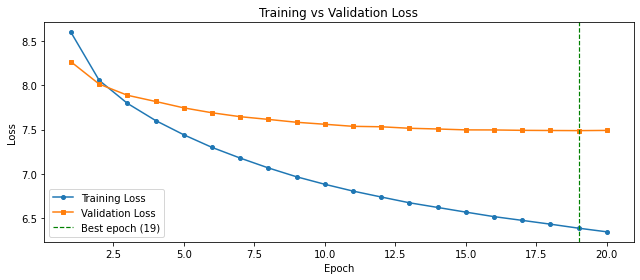

In [95]:
fig, ax = plt.subplots(figsize=(9, 4))
epochs_range = range(1, len(train_losses) + 1)
ax.plot(epochs_range, train_losses, label="Training Loss",   marker="o", markersize=4)
ax.plot(epochs_range, val_losses,   label="Validation Loss", marker="s", markersize=4)
ax.axvline(best_epoch, color="green", linestyle="--", linewidth=1.2,
           label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Validation Loss")
ax.legend()
fig.tight_layout()
plt.show()


### Beam Search Decoding

In [108]:
def beam_search_decode(src_tensor, beam_width=3, max_len=None):
    """Generate a summary for a single source tensor using beam search.

    Args:
        src_tensor : (1, src_len) — already on DEVICE
        beam_width : number of beams
        max_len    : maximum tokens to generate (defaults to TGT_MAX)

    Returns:
        str — decoded summary
    """
    if max_len is None:
        max_len = TGT_MAX

    model.eval()
    with torch.no_grad():
        enc_outputs, enc_hidden = model.encoder(src_tensor)

    # Each beam: (token_ids_list, hidden_state, cumulative_log_prob)
    beams     = [([SOS_IDX], enc_hidden, 0.0)]
    completed = []

    for _ in range(max_len):
        all_candidates = []

        for token_ids, hidden, score in beams:
            if token_ids[-1] == EOS_IDX:
                completed.append((token_ids, score))
                continue

            token = torch.tensor([token_ids[-1]], device=DEVICE)
            with torch.no_grad():
                logits, new_hidden, _ = model.decoder(token, hidden, enc_outputs)

            log_probs          = F.log_softmax(logits.squeeze(0), dim=-1)
            top_probs, top_idx = log_probs.topk(beam_width)

            for prob, idx in zip(top_probs.tolist(), top_idx.tolist()):
                # Suppress immediate token repetition
                if len(token_ids) > 1 and idx == token_ids[-1]:
                    continue
                all_candidates.append((token_ids + [idx], new_hidden, score + prob))

        if not all_candidates:
            break

        # Sort by length-normalised score (mild length penalty)
        def score_with_penalty(candidate):
            token_ids = candidate[0]
            repeat_penalty = sum(
                1 for j in range(1, len(token_ids)) 
                if token_ids[j] == token_ids[j-1]
            ) * 0.5
            return candidate[2] / len(token_ids) - repeat_penalty

        all_candidates.sort(key=score_with_penalty, reverse=True)
        beams = all_candidates[:beam_width]

    if not completed:
        completed = [(b[0], b[2]) for b in beams]

    best_ids, _ = max(completed, key=lambda x: x[1] / max(len(x[0]), 1))

    special = {SOS_IDX, EOS_IDX, PAD_IDX, vocab.unk_idx}
    words   = [vocab.idx2word[i] for i in best_ids if i not in special and i in vocab.idx2word]
    return " ".join(words)


### Qualitative Decoding Example

In [109]:
sample_batch = next(iter(test_loader))
i = 0
src_sample = sample_batch["src"][i:i+1].to(DEVICE)

print("ORIGINAL TEXT:")
print(df_test["text"].iloc[i][:300])
print("\nREAL SUMMARY:")
print(vocab.decode(sample_batch["tgt_output"][i].tolist()))
print("\nGENERATED SUMMARY:")
print(beam_search_decode(src_sample, beam_width=6))


ORIGINAL TEXT:
الجهات الحكومية بتجمع بيانات وإحصائيات بشكل دوري عن معدلات المواليد والخصوبة واستخدام وسائل تنظيم الأسرة، عشان تقيم مدى نجاح الاستراتيجيات وتحدد المناطق اللي محتاجة تركيز أكتر. كمان بتدعم الأبحاث العلمية اللي بتساعد في تطوير برامج وخطط جديدة تكون أكتر فعالية وتناسب الاحتياجات المتغيرة للمجتمع.

REAL SUMMARY:
الحكومه بتجمع بيانات واحصاييات وتقوم بابحاث مستمره لتقييم استراتيجيات تنظيم الاسره وتطويرها وتحديد المناطق الاكثر <UNK> للتدخلات الفعاله

GENERATED SUMMARY:
التخطيط البنيه التحتيه في الخدمات زي المدن زي زي التحتيه


### ROUGE Evaluation

In [89]:
class ArabicTokenizerROUGE:
    """Custom tokenizer for rouge_score that handles Arabic text."""
    def tokenize(self, text):
        text = re.sub(r"[^\u0600-\u06FF\s]", " ", str(text))
        return re.sub(r"\s+", " ", text).strip().split()

rouge_scorer_obj = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    tokenizer=ArabicTokenizerROUGE()
)


In [2]:
rouge1_scores, rouge2_scores, rougeL_scores = [], [], []

model.eval()
count = 0

for batch in test_loader:
    src_batch        = batch["src"].to(DEVICE)
    tgt_output_batch = batch["tgt_output"]

    for j in range(src_batch.size(0)):
        src_sample   = src_batch[j:j+1]
        real_summary = vocab.decode(tgt_output_batch[j].tolist())
        gen_summary  = beam_search_decode(src_sample, beam_width=6)

        scores = rouge_scorer_obj.score(real_summary, gen_summary)
        rouge1_scores.append(scores["rouge1"].fmeasure)
        rouge2_scores.append(scores["rouge2"].fmeasure)
        rougeL_scores.append(scores["rougeL"].fmeasure)
        count += 1

print(f"Evaluated on {count} samples (best epoch: {best_epoch}, val loss: {best_val_loss:.4f})")
print(f"Average ROUGE-1 : {sum(rouge1_scores)/count:.4f}")
print(f"Average ROUGE-2 : {sum(rouge2_scores)/count:.4f}")
print(f"Average ROUGE-L : {sum(rougeL_scores)/count:.4f}")

Evaluated on 4283 samples (best epoch: 7, val loss: 7.4413)
Average ROUGE-1 : 0.3628
Average ROUGE-2 : 27599
Average ROUGE-L : 0.3477


### Save & Load Model Checkpoint

The best checkpoint was already saved to `CONFIG["checkpoint_path"]` during
training and restored automatically.  The cell below shows how to reload it
in a fresh session.


In [47]:
# ── Reload in a fresh session ────────────────────────────────────────────
# checkpoint = torch.load(CONFIG["checkpoint_path"], map_location=DEVICE)
# model.load_state_dict(checkpoint["model_state_dict"])
# optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
# best_epoch = checkpoint["epoch"]
# print(f"Loaded checkpoint from epoch {best_epoch}, "
#       f"val loss {checkpoint['val_loss']:.4f}")


In [48]:
print(len(df_train), len(df_valid), len(df_test))


21889 2768 2747


In [110]:
# ── Quick inference test ──────────────────────────────────────────
test_articles = [
    df_test["text"].iloc[0],
    df_test["text"].iloc[1],
    df_test["text"].iloc[2],
]

model.eval()
for i, article in enumerate(test_articles):
    tokens     = preprocess(article)
    src_tensor = encode_and_pad(tokens, vocab, MAX_SRC_LEN).unsqueeze(0).to(DEVICE)
    generated  = beam_search_decode(src_tensor, beam_width=6)
    real       = df_test["summarized_text"].iloc[i]

    print(f"{'─'*60}")
    print(f"ARTICLE  : {article[:200]}")
    print(f"REAL     : {real}")
    print(f"GENERATED: {generated}")
    print()

────────────────────────────────────────────────────────────
ARTICLE  : الجهات الحكومية بتجمع بيانات وإحصائيات بشكل دوري عن معدلات المواليد والخصوبة واستخدام وسائل تنظيم الأسرة، عشان تقيم مدى نجاح الاستراتيجيات وتحدد المناطق اللي محتاجة تركيز أكتر. كمان بتدعم الأبحاث العل
REAL     : الحكومة بتجمع بيانات وإحصائيات وتقوم بأبحاث مستمرة لتقييم استراتيجيات تنظيم الأسرة وتطويرها، وتحديد المناطق الأكثر احتياجًا للتدخلات الفعالة.
GENERATED: التخطيط البنيه التحتيه في الخدمات زي المدن زي زي التحتيه

────────────────────────────────────────────────────────────
ARTICLE  : تغير المناخ هو واحد من أكبر التحديات اللي بتواجه كوكبنا. ارتفاع درجة حرارة الأرض بيعمل مشاكل زي ذوبان الجليد، ارتفاع منسوب سطح البحر، وتغيرات في أنماط الطقس اللي بتسبب فيضانات وجفاف شديدين في أماكن كت
REAL     : تغير المناخ وارتفاع حرارة الأرض بيسببوا ذوبان الجليد وارتفاع منسوب البحر وتغيرات جوية قاسية، وده بيهدد الزراعة والأمن الغذائي.
GENERATED: الهندسه الزراعيه في الزراعيه في الزراعيه في الزراعيه وده في وده في وده

───────────